In [1]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42

from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
def corr_plot(corr_matrix, save_name, figsize):


    g = sns.clustermap(
        corr_matrix,
        annot=False,
        cmap='coolwarm',
        square=True,
        linewidths=.5,
        cbar_pos=None,          
        dendrogram_ratio=0.15,  
        figsize=figsize,
        row_cluster=True,
        col_cluster=True,
        yticklabels=True,
        xticklabels = True,
        tree_kws={'linewidths': 1.0}
    )

    g.ax_heatmap.yaxis.tick_left()
    g.ax_heatmap.yaxis.set_label_position('left')

    heatmap_pos = g.ax_heatmap.get_position()
    row_dend_pos = g.ax_row_dendrogram.get_position()

    g.ax_row_dendrogram.set_position([heatmap_pos.x1,
                                      row_dend_pos.y0, 
                                     row_dend_pos.width, row_dend_pos.height])

    g.ax_row_dendrogram.invert_xaxis()

    cbar_ax = g.fig.add_axes([heatmap_pos.x1 + 0.2, 0.5, 0.03, 0.2])  
    cbar_ax.set_title('Correlation', fontsize=12, pad=10)
    g.fig.colorbar(g.ax_heatmap.collections[0], cax=cbar_ax)

    g.ax_heatmap.set_xlabel('Mouse Brain celltype', fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel('Lamprey Brain celltype', fontsize=14, fontweight='bold')

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

    plt.savefig(save_name, bbox_inches = 'tight')
    plt.close()

In [3]:
import plotly.graph_objects as go
import numpy as np

def plot_sankey_from_corr(corr_matrix, threshold=0.3, output_path=None):

    lamprey_labels = list(corr_matrix.index)
    mouse_labels = list(corr_matrix.columns)
    all_labels = lamprey_labels + mouse_labels
    
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
    
    sources = []
    targets = []
    values = []
    colors = []
    
    for i, lamprey_type in enumerate(lamprey_labels):
        for j, mouse_type in enumerate(mouse_labels):
            corr_val = corr_matrix.loc[lamprey_type, mouse_type]
            
            if corr_val > threshold:
                sources.append(label_to_idx[lamprey_type])
                targets.append(label_to_idx[mouse_type])
                values.append(corr_val)
                
                alpha = min(corr_val, 1.0)
                colors.append(f'rgba(31, 119, 180, {alpha})')
    
    node_colors = ['rgba(255, 127, 14, 0.8)'] * len(lamprey_labels) + \
                  ['rgba(44, 160, 44, 0.8)'] * len(mouse_labels)
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors
        )
    )])
    
    fig.update_layout(
        title_text="Lamprey-Mouse Cell Type Correlation Sankey",
        font_size=10,
        height=1200,
        width=1000
    )
    
    if output_path:
        if output_path.endswith('.html'):
            fig.write_html(output_path)
        else:
            fig.write_image(output_path)
    
    fig.show()
    return fig



In [4]:
adata = sc.read_h5ad('/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/scvi_corrected.h5ad')
adata

AnnData object with n_obs × n_vars = 250800 × 6992
    obs: 'region', 'slices', 'ax', 'ay', 'az', 'celltype', 'species', 'n_counts', 'log_counts', 'n_genes'
    var: 'n_cells', 'mean-0', 'std-0', 'mean-1', 'std-1'
    obsm: 'aligned_scvi'
    layers: 'counts'

In [5]:
dic = {
    '1': 'mouse',
    '0': 'lamprey',
}
adata.obs['species'] = [dic[i] for i in adata.obs['species']]

In [6]:
csv1=pd.read_csv('/data/users/wuhaixu/online/240726_newScviMerge/metadata/lamprey.Cb.anno_whole_cluster.csv', index_col = 'Unnamed: 0')
csv2=pd.read_csv('/data/users/wuhaixu/online/240726_newScviMerge/metadata/lamprey.Mid.anno_whole_cluster.csv', index_col = 'Unnamed: 0')
csv3=pd.read_csv('/data/users/wuhaixu/online/240726_newScviMerge/metadata/lamprey.Rh.anno_whole_cluster.csv', index_col = 'Unnamed: 0')
csv4=pd.read_csv('/data/users/wuhaixu/online/240726_newScviMerge/metadata/lamprey.Pin.anno_whole_cluster.csv', index_col = 'Unnamed: 0')
csv=pd.concat([csv1,csv2,csv3, csv4])
inte = list(set(csv.index.tolist()) & set(adata[adata.obs['species'] == 'lamprey'].obs.index.tolist()))
csv = csv.loc[inte].copy()
lamprey_adata = adata[inte].copy()
mouse_adata = adata[adata.obs['species']=='mouse'].copy()
lamprey_adata.obs['celltype'] = csv['anno_whole_cluster'].tolist()
adata = ad.concat([mouse_adata, lamprey_adata])

In [7]:
adata.obs

,region,slices,ax,ay,az,celltype,species,n_counts,log_counts,n_genes
15534-30,RCB-CBX-CBXmo,T349,569.061000,259.990000,1042.0,Astrocytes,mouse,524.0,6.261492,302
6505-39,RCB-CBX-CBXmo,T369,656.350000,307.534000,1234.0,Astrocytes,mouse,583.0,6.368187,371
10702-37,RCB-CBX-CBXmo,T369,638.446000,402.365000,1234.0,Endothelial cells,mouse,527.0,6.267201,339
15030-29,RCB-CBX-CBXmo,T349,593.736000,261.957000,1042.0,Oligodendrocytes,mouse,653.0,6.481577,349
27952-25,RCB-CBX-CBXmo,T349,603.623000,369.832000,1042.0,Ependymal cells,mouse,138.0,4.927254,88
...,...,...,...,...,...,...,...,...,...,...
61150-24-24,griseum_centrale_rhombencephali,25,5.755953,16.109214,4.0,Rh-Neu-1,lamprey,526.0,6.265301,245
29221-2-2,areae_octavolateralis,3,8.013377,18.800934,8.4,Cb-Neu-8,lamprey,173.0,5.153292,85
46930-25-25,areae_octavolateralis,26,9.368328,21.059092,3.8,Cb-Neu-1,lamprey,138.0,4.927254,91
55647-20-20,griseum_centrale_rhombencephali,21,6.523147,17.008590,4.8,Rh-Neu-1,lamprey,124.0,4.820282,72


In [8]:
adata.obs['celltype'] = adata.obs['species'].astype(str) +'_'+ adata.obs['celltype'].astype(str)

In [9]:
df = pd.DataFrame(adata.obs['celltype'].value_counts())
df = df[df['celltype']>100]
temp = adata[adata.obs['celltype'].isin(df.index.tolist())]
temp

View of AnnData object with n_obs × n_vars = 250294 × 6992
    obs: 'region', 'slices', 'ax', 'ay', 'az', 'celltype', 'species', 'n_counts', 'log_counts', 'n_genes'
    obsm: 'aligned_scvi'
    layers: 'counts'

In [10]:
set(temp.obs['celltype'])

{'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7',
 'lamprey_Rh-Neu-8',
 'lamprey_Rh-Neu-9',
 'mouse_Astrocytes',
 'mouse_Cerebral nuclei neuroblasts',
 'mouse_Cholinergic, monoaminergic, peptidergic neurons',
 'mouse_Choroid plexus epithelial cells',
 'mouse_Di- and mesencephalon neurons',
 'mouse_Endothelial cells',
 'mouse_Ependymal cel

In [11]:
raw_indexs = [
'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7',
 'lamprey_Rh-Neu-8',
 'lamprey_Rh-Neu-9',
]
raw_columns = ['mouse_Astrocytes',
 'mouse_Cerebral nuclei neuroblasts',
 'mouse_Cholinergic, monoaminergic, peptidergic neurons',
 'mouse_Choroid plexus epithelial cells',
 'mouse_Dentate gyrus granule neurons',
 'mouse_Di- and mesencephalon neurons',
 'mouse_Endothelial cells',
 'mouse_Ependymal cells',
 'mouse_Hypendymal cells',
 'mouse_Microglia',
 'mouse_Olfactory bulb inhibitory neurons',
 'mouse_Oligodendrocyte precursor cells',
 'mouse_Oligodendrocytes',
 'mouse_Rhombencephalon neurons',
 'mouse_Telencephalon excitatory neurons',
 'mouse_Telencephalon inhibitory neurons',
 'mouse_Vascular and leptomeningeal cells']
scvi_repr = adata.obsm['aligned_scvi']
cell_types = adata.obs['celltype'].values
df = pd.DataFrame(scvi_repr, index=adata.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/01_20251223/Pons_1.pdf', (6,11))

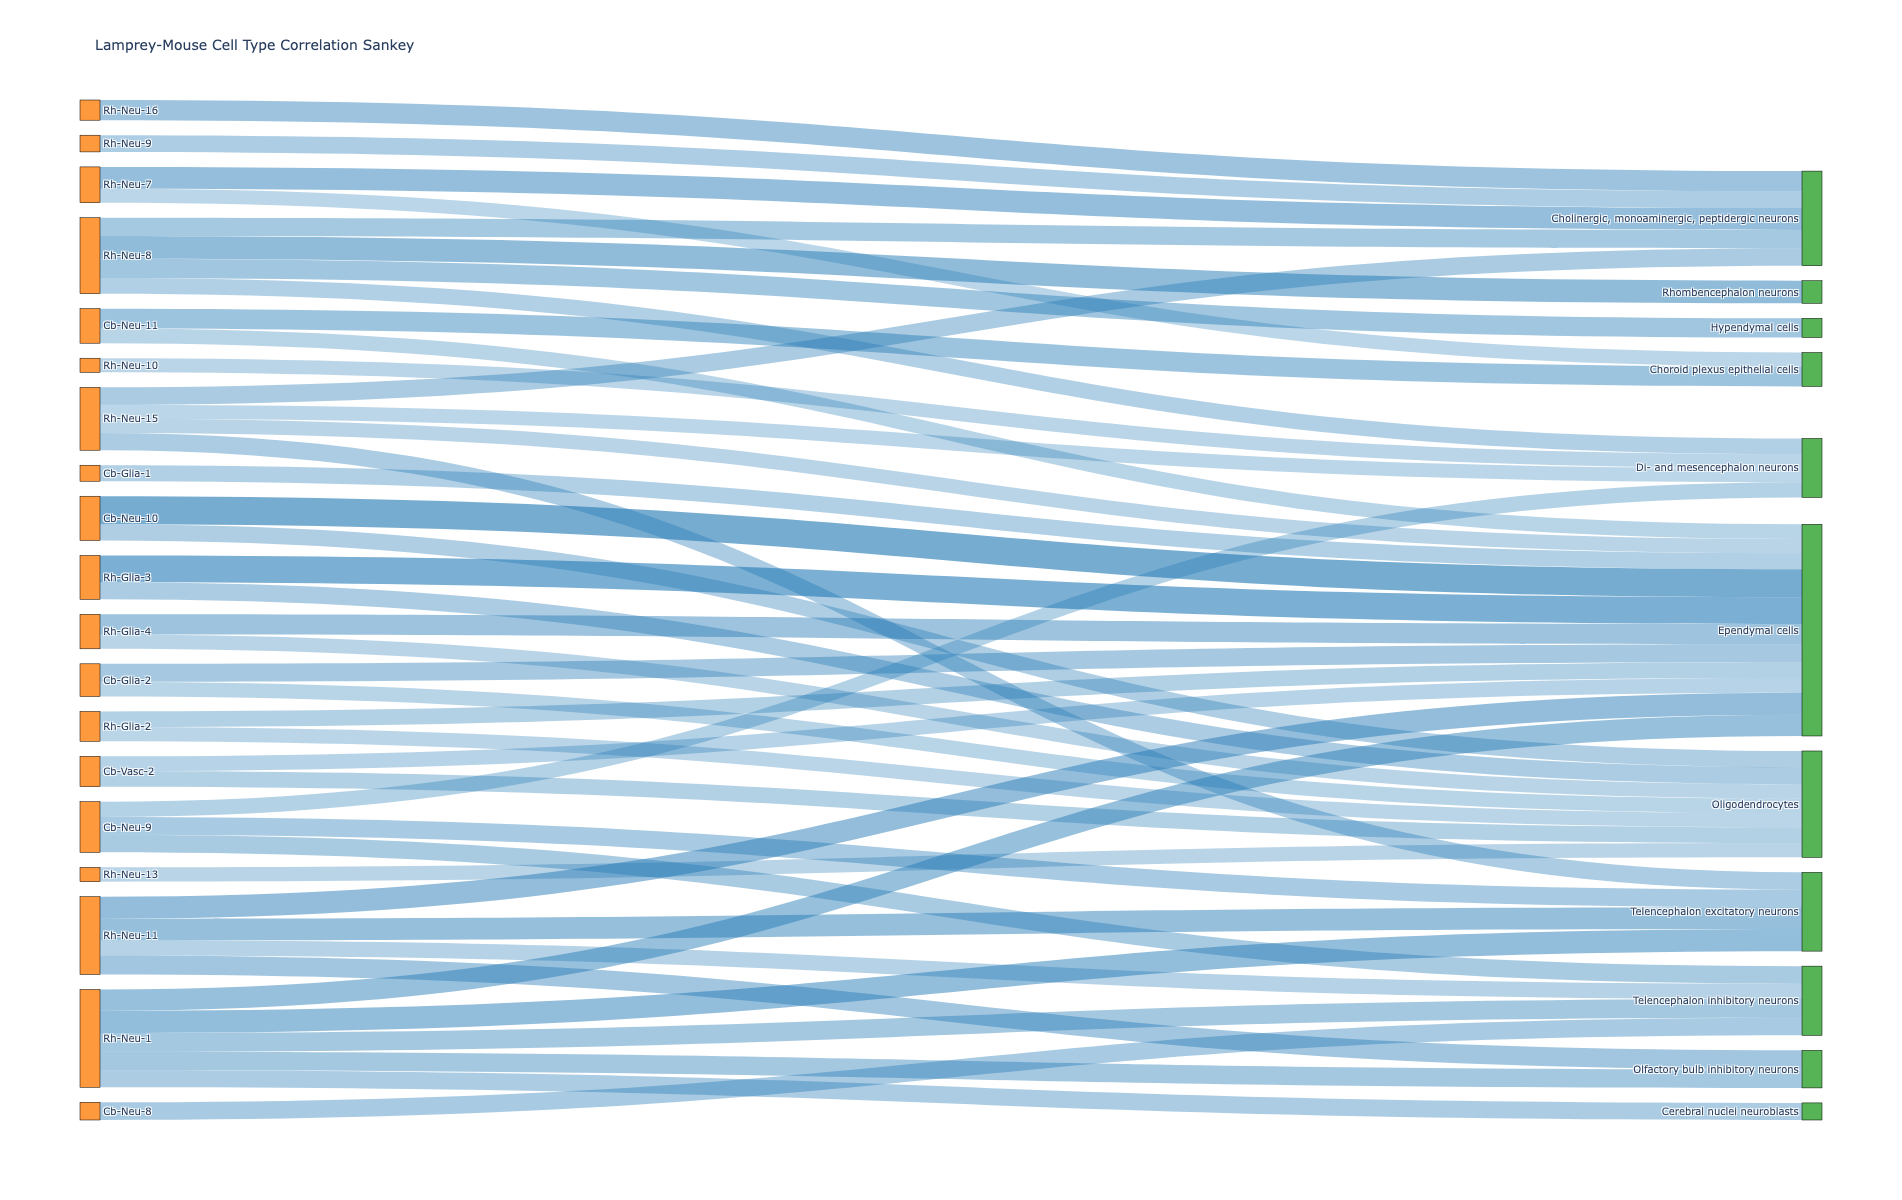

In [12]:
fig = plot_sankey_from_corr(corr_matrix, threshold=0.3, )
fig.write_html('/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/01_20251223/Pons_1.html')

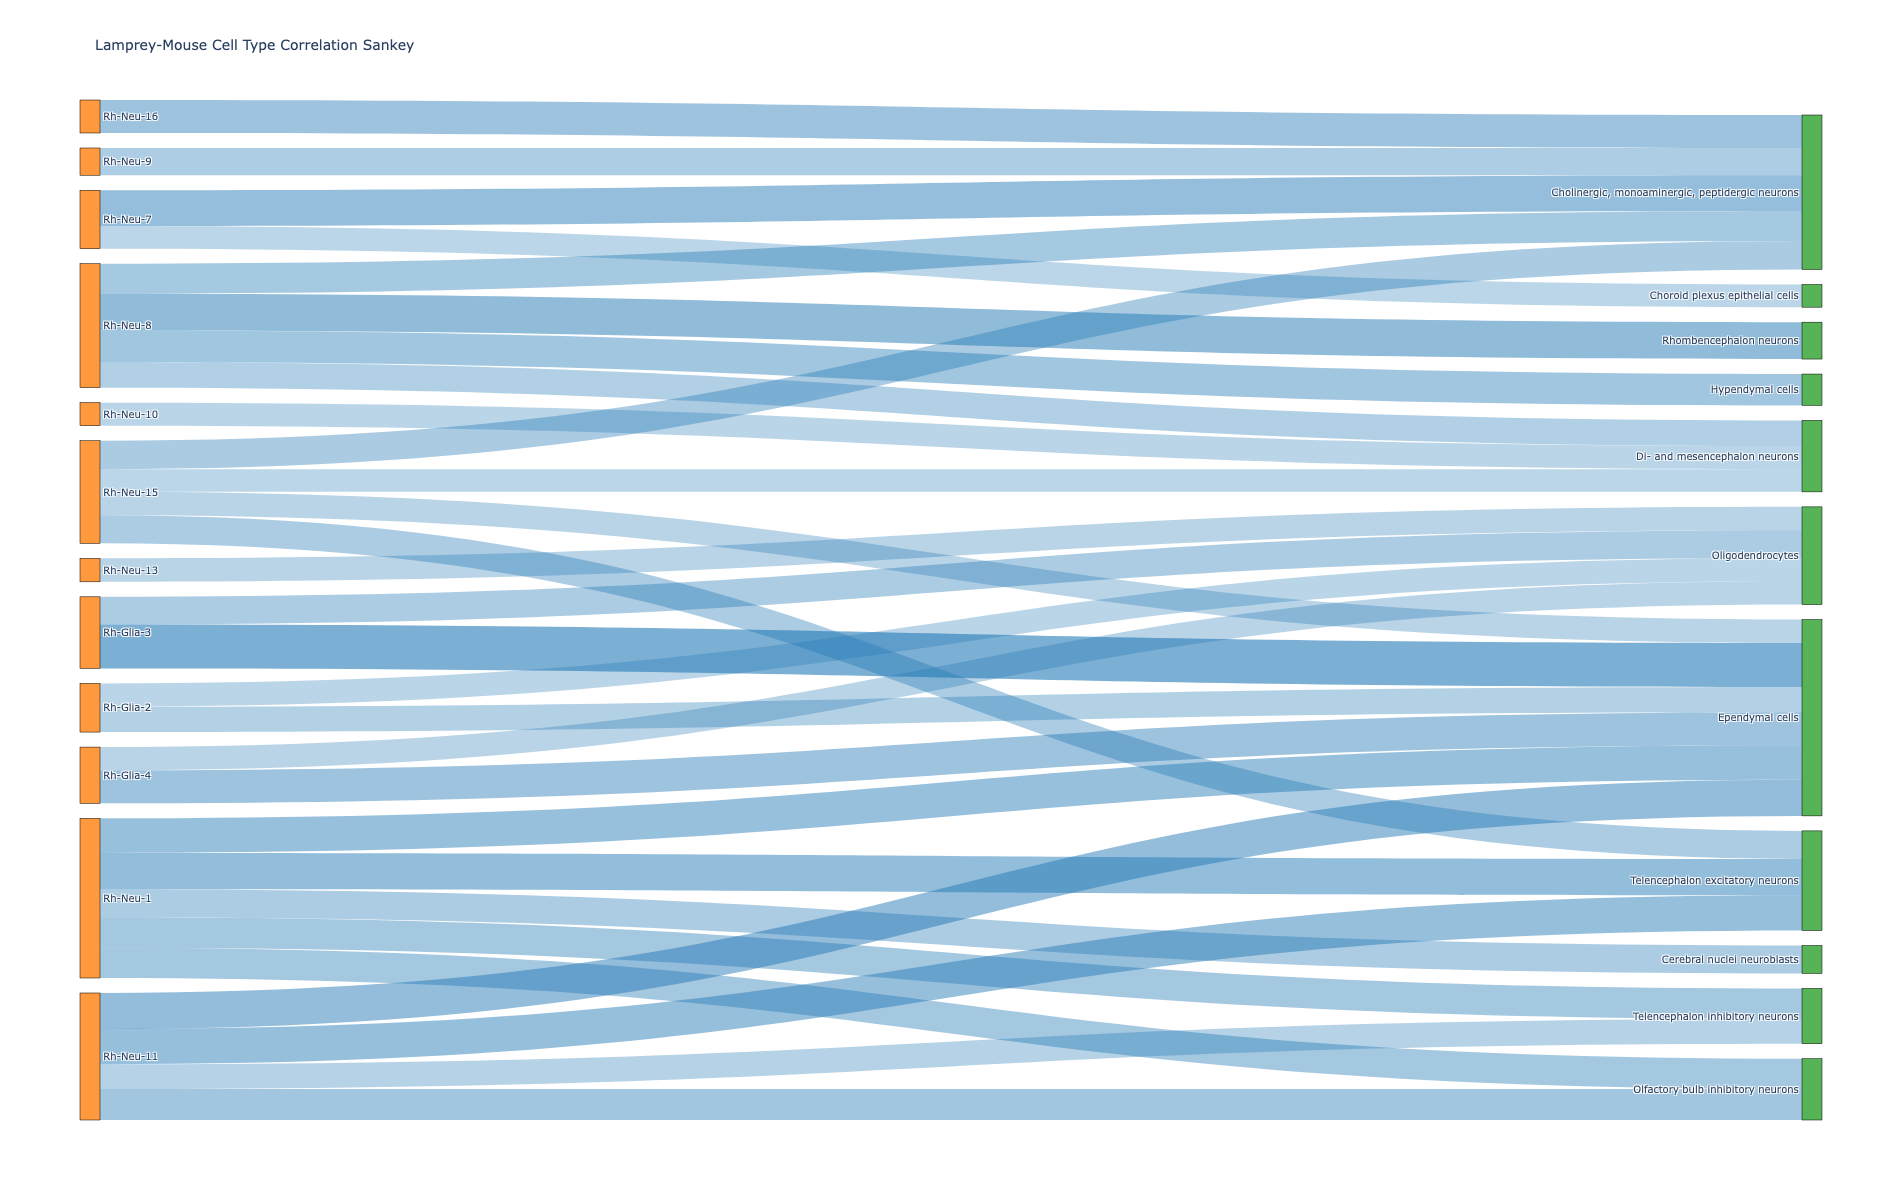

In [14]:
raw_indexs = [

 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7',
 'lamprey_Rh-Neu-8',
 'lamprey_Rh-Neu-9',
]
raw_columns = ['mouse_Astrocytes',
 'mouse_Cerebral nuclei neuroblasts',
 'mouse_Cholinergic, monoaminergic, peptidergic neurons',
 'mouse_Choroid plexus epithelial cells',
 'mouse_Dentate gyrus granule neurons',
 'mouse_Di- and mesencephalon neurons',
 'mouse_Endothelial cells',
 'mouse_Ependymal cells',
 'mouse_Hypendymal cells',
 'mouse_Microglia',
 'mouse_Olfactory bulb inhibitory neurons',
 'mouse_Oligodendrocyte precursor cells',
 'mouse_Oligodendrocytes',
 'mouse_Rhombencephalon neurons',
 'mouse_Telencephalon excitatory neurons',
 'mouse_Telencephalon inhibitory neurons',
 'mouse_Vascular and leptomeningeal cells']
scvi_repr = adata.obsm['aligned_scvi']
cell_types = adata.obs['celltype'].values
df = pd.DataFrame(scvi_repr, index=adata.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/01_20251223/Pons_2.pdf', (6,8))
fig = plot_sankey_from_corr(corr_matrix, threshold=0.3, )
fig.write_html('/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/01_20251223/Pons_2.html')

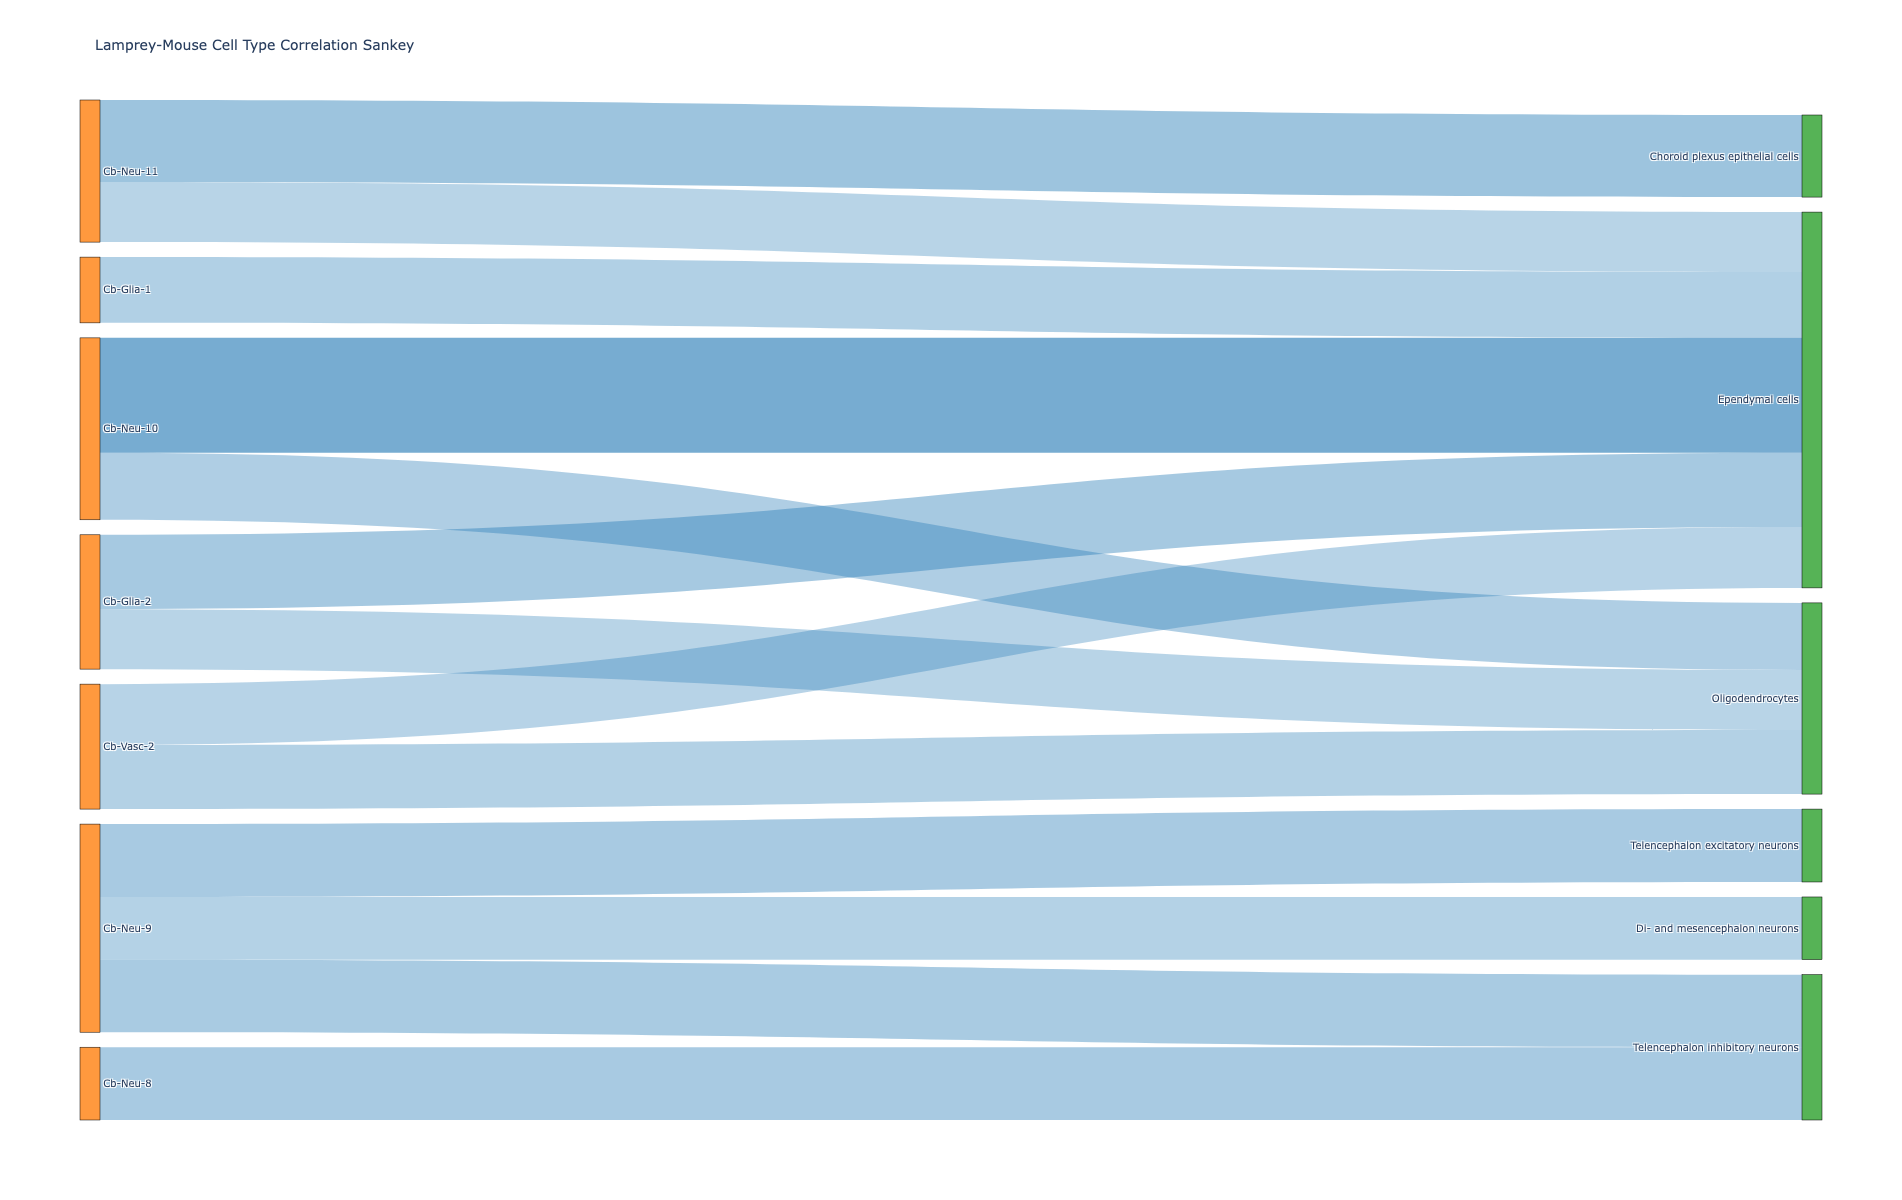

In [15]:
raw_indexs = [
'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',

]
raw_columns = ['mouse_Astrocytes',
 'mouse_Cerebral nuclei neuroblasts',
 'mouse_Cholinergic, monoaminergic, peptidergic neurons',
 'mouse_Choroid plexus epithelial cells',
 'mouse_Dentate gyrus granule neurons',
 'mouse_Di- and mesencephalon neurons',
 'mouse_Endothelial cells',
 'mouse_Ependymal cells',
 'mouse_Hypendymal cells',
 'mouse_Microglia',
 'mouse_Olfactory bulb inhibitory neurons',
 'mouse_Oligodendrocyte precursor cells',
 'mouse_Oligodendrocytes',
 'mouse_Rhombencephalon neurons',
 'mouse_Telencephalon excitatory neurons',
 'mouse_Telencephalon inhibitory neurons',
 'mouse_Vascular and leptomeningeal cells']
scvi_repr = adata.obsm['aligned_scvi']
cell_types = adata.obs['celltype'].values
df = pd.DataFrame(scvi_repr, index=adata.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/01_20251223/Pons_3.pdf', (6,8))
fig = plot_sankey_from_corr(corr_matrix, threshold=0.3, )
fig.write_html('/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/01_20251223/Pons_3.html')

In [11]:
mouse = sc.read_h5ad('/data/work/22.fusemap/01.datas/08.Pons/mouse_brain_stereo_3d.h5ad')
lamprey_adata = adata[adata.obs['species'] == 'lamprey'].copy()
mouse_adata = adata[adata.obs['species'] == 'mouse'].copy()

mouse_index= mouse_adata.obs.index.tolist()
inte = list(set(mouse.obs.index.tolist()) & set(mouse_adata.obs.index.tolist()))
mouse = mouse[inte]
mouse_adata = mouse_adata[inte]

mouse_celltype = 'mouse_' + mouse.obs['cell_cluster'].astype(str)
mouse_celltype = mouse_celltype.tolist()
lamprey_celltype = lamprey_adata.obs['celltype'].tolist()

In [14]:
1

1

In [15]:
new_celltype =  mouse_celltype+ lamprey_celltype
adata = ad.concat([mouse_adata, lamprey_adata])

In [19]:
adata.obs['new_celltype'] = new_celltype

In [20]:
adata.obs

,region,slices,ax,ay,az,celltype,species,n_counts,log_counts,n_genes,new_celltype
55054-52,LP-Psen-PSV,T352,341.343000,626.481000,1065.0,mouse_Astrocytes,mouse,436.0,6.077642,233,mouse_ASC_279
22070-50,LCB-CBX-CBXgr,T368,475.327000,176.431000,1224.0,mouse_Oligodendrocytes,mouse,521.0,6.255750,335,mouse_OL_301
42085-43,LCB-CBX-CBXgr,T366,183.191000,369.993000,1204.0,mouse_Rhombencephalon neurons,mouse,476.0,6.165418,273,mouse_CB_PKC_GABA_262
49670-56,LCB-CBX-CBXgr,T350,288.730000,603.089000,1064.0,mouse_Vascular and leptomeningeal cells,mouse,474.0,6.161207,236,mouse_VLMC_271
33551-18,LCB-CBX-CBXmo,T349,368.176000,423.545000,1042.0,mouse_Astrocytes,mouse,862.0,6.759255,452,mouse_ASC_283
...,...,...,...,...,...,...,...,...,...,...,...
51871-26-26,nucleus_of_X,27,8.073156,26.408507,3.6,lamprey_Rh-Neu-2,lamprey,170.0,5.135798,89,lamprey_Rh-Neu-2
30881-8-8,areae_octavolateralis,9,10.497200,25.793810,7.2,lamprey_Rh-Neu-1,lamprey,505.0,6.224558,234,lamprey_Rh-Neu-1
836,areae_octavolateralis,8,8.174671,23.172330,7.4,lamprey_Rh-Neu-2,lamprey,140.0,4.941642,60,lamprey_Rh-Neu-2
43416-33-33,nucleus_of_the_radix_descendens_nervi_trigemini,34,6.432779,23.039264,2.2,lamprey_Rh-Neu-6,lamprey,165.0,5.105945,70,lamprey_Rh-Neu-6


In [21]:
set(adata.obs['new_celltype'])

{'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Mid-Glia-1',
 'lamprey_Mid-Glia-2',
 'lamprey_Mid-Neu-1',
 'lamprey_Mid-Neu-10',
 'lamprey_Mid-Neu-12',
 'lamprey_Mid-Neu-14',
 'lamprey_Mid-Neu-15',
 'lamprey_Mid-Neu-3',
 'lamprey_Mid-Neu-5',
 'lamprey_Mid-Neu-6',
 'lamprey_Mid-Neu-8',
 'lamprey_Mid-Neu-9',
 'lamprey_Mid-Vasc-1',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7

In [25]:
raw_indexs = [
'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Mid-Glia-1',
 'lamprey_Mid-Glia-2',
 'lamprey_Mid-Neu-1',
 'lamprey_Mid-Neu-10',
 'lamprey_Mid-Neu-12',
 'lamprey_Mid-Neu-14',
 'lamprey_Mid-Neu-15',
 'lamprey_Mid-Neu-3',
 'lamprey_Mid-Neu-5',
 'lamprey_Mid-Neu-6',
 'lamprey_Mid-Neu-8',
 'lamprey_Mid-Neu-9',
 'lamprey_Mid-Vasc-1',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7',
 'lamprey_Rh-Neu-8',
 'lamprey_Rh-Neu-9',
]
raw_columns = [ 'mouse_ASC_275',
 'mouse_ASC_276',
 'mouse_ASC_277',
 'mouse_ASC_278',
 'mouse_ASC_279',
 'mouse_ASC_280',
 'mouse_ASC_281',
 'mouse_ASC_282',
 'mouse_ASC_283',
 'mouse_CB_GRC_GLU_261',
 'mouse_CB_PKC_GABA_262',
 'mouse_CHOR_287',
 'mouse_CHOR_288',
 'mouse_CNU_N_GABA_136',
 'mouse_CNU_N_GABA_137',
 'mouse_CNU_N_GABA_138',
 'mouse_CNU_N_GABA_139',
 'mouse_CNU_N_GABA_140',
 'mouse_CNU_N_GABA_141',
 'mouse_CNU_N_GABA_142',
 'mouse_CNU_N_GABA_143',
 'mouse_CNU_N_GABA_144',
 'mouse_CNU_N_GABA_145',
 'mouse_CNU_N_GABA_146',
 'mouse_CNU_N_GABA_147',
 'mouse_CNU_N_GABA_148',
 'mouse_CNU_N_GABA_149',
 'mouse_CNU_N_GABA_150',
 'mouse_CNU_N_GABA_151',
 'mouse_CNU_N_GABA_152',
 'mouse_CNU_N_GABA_153',
 'mouse_CNU_N_GABA_154',
 'mouse_CNU_N_GABA_155',
 'mouse_CNU_N_GABA_156',
 'mouse_CNU_N_GABA_157',
 'mouse_CNU_N_GABA_158',
 'mouse_CNU_N_GABA_159',
 'mouse_DG_N_GLU_93',
 'mouse_DIME_N_AVP_226',
 'mouse_DIME_N_DOP_225',
 'mouse_DIME_N_GABA_245',
 'mouse_DIME_N_GAL_227',
 'mouse_DIME_N_GLU_192',
 'mouse_DIME_N_GLU_195',
 'mouse_DIME_N_GLU_196',
 'mouse_DIME_N_GLU_198',
 'mouse_DIME_N_GLU_201',
 'mouse_DIME_N_GLU_202',
 'mouse_DIME_N_GLU_203',
 'mouse_DIME_N_GLU_211',
 'mouse_DIME_N_GLU_212',
 'mouse_DIME_N_GLU_215',
 'mouse_DIME_N_GLU_216',
 'mouse_EDC_263',
 'mouse_EDC_264',
 'mouse_EDC_265',
 'mouse_EDC_266',
 'mouse_EPC_284',
 'mouse_EPC_285',
 'mouse_HYPC_286',
 'mouse_L5_PT_GLU_53',
 'mouse_L6_IT_GLU_51',
 'mouse_L6_N_GLU_69',
 'mouse_MGL_289',
 'mouse_MGL_290',
 'mouse_MGL_291',
 'mouse_MGL_292',
 'mouse_MGL_293',
 'mouse_OB_N_GABA_160',
 'mouse_OB_N_GABA_163',
 'mouse_OB_N_GABA_168',
 'mouse_OL_294',
 'mouse_OL_295',
 'mouse_OL_296',
 'mouse_OL_297',
 'mouse_OL_298',
 'mouse_OL_299',
 'mouse_OL_300',
 'mouse_OL_301',
 'mouse_OL_302',
 'mouse_OL_303',
 'mouse_OL_304',
 'mouse_OL_305',
 'mouse_OPC_306',
 'mouse_OPC_307',
 'mouse_OPC_308',
 'mouse_RH_N_CHO_233',
 'mouse_RH_N_CHO_234',
 'mouse_RH_N_GABA_241',
 'mouse_RH_N_GABA_242',
 'mouse_RH_N_GABA_250',
 'mouse_RH_N_GABA_251',
 'mouse_RH_N_GABA_255',
 'mouse_RH_N_GABA_256',
 'mouse_RH_N_GABA_257',
 'mouse_RH_N_GLU_210',
 'mouse_RH_N_GLU_219',
 'mouse_RH_N_GLU_220',
 'mouse_RH_N_GLU_237',
 'mouse_RH_N_GLU_239',
 'mouse_RH_N_GLU_240',
 'mouse_RH_N_GLU_252',
 'mouse_RH_N_GLU_253',
 'mouse_RH_N_GLU_254',
 'mouse_RH_N_GLU_258',
 'mouse_RH_N_GLU_259',
 'mouse_RH_N_GLU_260',
 'mouse_RH_N_NOR_231',
 'mouse_RH_N_SER_229',
 'mouse_RH_N_SER_230',
 'mouse_STR_NBL_221',
 'mouse_STR_NBL_222',
 'mouse_TE_N_CHO_235',
 'mouse_TE_N_CHO_236',
 'mouse_TE_N_GABA_133',
 'mouse_TE_N_GABA_134',
 'mouse_TE_N_GABA_135',
 'mouse_TE_N_GABA_CHODL_131',
 'mouse_TE_N_GABA_CHODL_132',
 'mouse_TE_N_GABA_LAMP5_96',
 'mouse_TE_N_GABA_LAMP5_97',
 'mouse_TE_N_GABA_LAMP5_98',
 'mouse_TE_N_GABA_PVALB_113',
 'mouse_TE_N_GABA_PVALB_114',
 'mouse_TE_N_GABA_PVALB_115',
 'mouse_TE_N_GABA_PVALB_116',
 'mouse_TE_N_GABA_PVALB_118',
 'mouse_TE_N_GABA_RELN_104',
 'mouse_TE_N_GABA_RELN_107',
 'mouse_TE_N_GABA_RELN_108',
 'mouse_TE_N_GABA_RELN_109',
 'mouse_TE_N_GABA_RELN_110',
 'mouse_TE_N_GABA_SNCG_101',
 'mouse_TE_N_GABA_SNCG_102',
 'mouse_TE_N_GABA_SNCG_103',
 'mouse_TE_N_GABA_SNCG_105',
 'mouse_TE_N_GABA_SST_120',
 'mouse_TE_N_GABA_SST_122',
 'mouse_TE_N_GABA_SST_123',
 'mouse_TE_N_GABA_SST_124',
 'mouse_TE_N_GABA_SST_127',
 'mouse_TE_N_GABA_SST_128',
 'mouse_TE_N_GABA_SST_129',
 'mouse_TE_N_GABA_SST_130',
 'mouse_TE_N_GABA_VIP_106',
 'mouse_TE_N_GABA_VIP_111',
 'mouse_TE_N_GABA_VIP_112',
 'mouse_TE_N_GLU_1',
 'mouse_TE_N_GLU_10',
 'mouse_TE_N_GLU_11',
 'mouse_TE_N_GLU_12',
 'mouse_TE_N_GLU_18',
 'mouse_TE_N_GLU_19',
 'mouse_TE_N_GLU_2',
 'mouse_TE_N_GLU_20',
 'mouse_TE_N_GLU_23',
 'mouse_TE_N_GLU_24',
 'mouse_TE_N_GLU_25',
 'mouse_TE_N_GLU_26',
 'mouse_TE_N_GLU_27',
 'mouse_TE_N_GLU_28',
 'mouse_TE_N_GLU_3',
 'mouse_TE_N_GLU_30',
 'mouse_TE_N_GLU_4',
 'mouse_TE_N_GLU_5',
 'mouse_TE_N_GLU_6',
 'mouse_TE_N_GLU_7',
 'mouse_TE_N_GLU_8',
 'mouse_TE_N_GLU_9',
 'mouse_VLMC_267',
 'mouse_VLMC_268',
 'mouse_VLMC_269',
 'mouse_VLMC_270',
 'mouse_VLMC_271',
 'mouse_VLMC_272',
 'mouse_VLMC_273',
 'mouse_VLMC_274']
scvi_repr = adata.obsm['aligned_scvi']
cell_types = adata.obs['new_celltype'].values
df = pd.DataFrame(scvi_repr, index=adata.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/Pons_2.pdf', (44,14))

In [26]:
raw_indexs = [
'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Mid-Glia-1',
 'lamprey_Mid-Glia-2',
 'lamprey_Mid-Neu-1',
 'lamprey_Mid-Neu-10',
 'lamprey_Mid-Neu-12',
 'lamprey_Mid-Neu-14',
 'lamprey_Mid-Neu-15',
 'lamprey_Mid-Neu-3',
 'lamprey_Mid-Neu-5',
 'lamprey_Mid-Neu-6',
 'lamprey_Mid-Neu-8',
 'lamprey_Mid-Neu-9',
 'lamprey_Mid-Vasc-1',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7',
 'lamprey_Rh-Neu-8',
 'lamprey_Rh-Neu-9',
]
raw_columns = [ 'mouse_ASC_275',
 'mouse_ASC_276',
 'mouse_ASC_277',
 'mouse_ASC_278',
 'mouse_ASC_279',
 'mouse_ASC_280',
 'mouse_ASC_281',
 'mouse_ASC_282',
 'mouse_ASC_283',
 'mouse_CB_GRC_GLU_261',
 'mouse_CB_PKC_GABA_262',
 'mouse_CHOR_287',
 'mouse_CHOR_288',
 'mouse_CNU_N_GABA_136',
 'mouse_CNU_N_GABA_137',
 'mouse_CNU_N_GABA_138',
 'mouse_CNU_N_GABA_139',
 'mouse_CNU_N_GABA_140',
 'mouse_CNU_N_GABA_141',
 'mouse_CNU_N_GABA_142',
 'mouse_CNU_N_GABA_143',
 'mouse_CNU_N_GABA_144',
 'mouse_CNU_N_GABA_145',
 'mouse_CNU_N_GABA_146',
 'mouse_CNU_N_GABA_147',
 'mouse_CNU_N_GABA_148',
 'mouse_CNU_N_GABA_149',
 'mouse_CNU_N_GABA_150',
 'mouse_CNU_N_GABA_151',
 'mouse_CNU_N_GABA_152',
 'mouse_CNU_N_GABA_153',
 'mouse_CNU_N_GABA_154',
 'mouse_CNU_N_GABA_155',
 'mouse_CNU_N_GABA_156',
 'mouse_CNU_N_GABA_157',
 'mouse_CNU_N_GABA_158',
 'mouse_CNU_N_GABA_159',
 'mouse_DG_N_GLU_93',
 'mouse_DIME_N_AVP_226',
 'mouse_DIME_N_DOP_225',
 'mouse_DIME_N_GABA_245',
 'mouse_DIME_N_GAL_227',
 'mouse_DIME_N_GLU_192',
 'mouse_DIME_N_GLU_195',
 'mouse_DIME_N_GLU_196',
 'mouse_DIME_N_GLU_198',
 'mouse_DIME_N_GLU_201',
 'mouse_DIME_N_GLU_202',
 'mouse_DIME_N_GLU_203',
 'mouse_DIME_N_GLU_211',
 'mouse_DIME_N_GLU_212',
 'mouse_DIME_N_GLU_215',
 'mouse_DIME_N_GLU_216',
 'mouse_EDC_263',
 'mouse_EDC_264',
 'mouse_EDC_265',
 'mouse_EDC_266',
 'mouse_EPC_284',
 'mouse_EPC_285',
 'mouse_HYPC_286',
 'mouse_MGL_289',
 'mouse_MGL_290',
 'mouse_MGL_291',
 'mouse_MGL_292',
 'mouse_MGL_293',
 'mouse_OL_294',
 'mouse_OL_295',
 'mouse_OL_296',
 'mouse_OL_297',
 'mouse_OL_298',
 'mouse_OL_299',
 'mouse_OL_300',
 'mouse_OL_301',
 'mouse_OL_302',
 'mouse_OL_303',
 'mouse_OL_304',
 'mouse_OL_305',
 'mouse_OPC_306',
 'mouse_OPC_307',
 'mouse_OPC_308',
 'mouse_RH_N_CHO_233',
 'mouse_RH_N_CHO_234',
 'mouse_RH_N_GABA_241',
 'mouse_RH_N_GABA_242',
 'mouse_RH_N_GABA_250',
 'mouse_RH_N_GABA_251',
 'mouse_RH_N_GABA_255',
 'mouse_RH_N_GABA_256',
 'mouse_RH_N_GABA_257',
 'mouse_RH_N_GLU_210',
 'mouse_RH_N_GLU_219',
 'mouse_RH_N_GLU_220',
 'mouse_RH_N_GLU_237',
 'mouse_RH_N_GLU_239',
 'mouse_RH_N_GLU_240',
 'mouse_RH_N_GLU_252',
 'mouse_RH_N_GLU_253',
 'mouse_RH_N_GLU_254',
 'mouse_RH_N_GLU_258',
 'mouse_RH_N_GLU_259',
 'mouse_RH_N_GLU_260',
 'mouse_RH_N_NOR_231',
 'mouse_RH_N_SER_229',
 'mouse_RH_N_SER_230',
 'mouse_VLMC_267',
 'mouse_VLMC_268',
 'mouse_VLMC_269',
 'mouse_VLMC_270',
 'mouse_VLMC_271',
 'mouse_VLMC_272',
 'mouse_VLMC_273',
 'mouse_VLMC_274']
scvi_repr = adata.obsm['aligned_scvi']
cell_types = adata.obs['new_celltype'].values
df = pd.DataFrame(scvi_repr, index=adata.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/Pons_3.pdf', (32,14))

In [27]:
mouse_region = ['mouse_'+i[1:] for i in adata[adata.obs['species'] == 'mouse'].obs['region'].tolist()]
lamprey_region = adata[adata.obs['species'] == 'lamprey'].obs['new_celltype'].tolist()
new_region = mouse_region+ lamprey_region
adata.obs['new_region'] = new_region

In [28]:
set(new_region)

{'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Mid-Glia-1',
 'lamprey_Mid-Glia-2',
 'lamprey_Mid-Neu-1',
 'lamprey_Mid-Neu-10',
 'lamprey_Mid-Neu-12',
 'lamprey_Mid-Neu-14',
 'lamprey_Mid-Neu-15',
 'lamprey_Mid-Neu-3',
 'lamprey_Mid-Neu-5',
 'lamprey_Mid-Neu-6',
 'lamprey_Mid-Neu-8',
 'lamprey_Mid-Neu-9',
 'lamprey_Mid-Vasc-1',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7

In [31]:
raw_indexs = [
'lamprey_Cb-Glia-1',
 'lamprey_Cb-Glia-2',
 'lamprey_Cb-Neu-1',
 'lamprey_Cb-Neu-10',
 'lamprey_Cb-Neu-11',
 'lamprey_Cb-Neu-2',
 'lamprey_Cb-Neu-3',
 'lamprey_Cb-Neu-4',
 'lamprey_Cb-Neu-5',
 'lamprey_Cb-Neu-6',
 'lamprey_Cb-Neu-7',
 'lamprey_Cb-Neu-8',
 'lamprey_Cb-Neu-9',
 'lamprey_Cb-Vasc-1',
 'lamprey_Cb-Vasc-2',
 'lamprey_Mid-Glia-1',
 'lamprey_Mid-Glia-2',
 'lamprey_Mid-Neu-1',
 'lamprey_Mid-Neu-10',
 'lamprey_Mid-Neu-12',
 'lamprey_Mid-Neu-14',
 'lamprey_Mid-Neu-15',
 'lamprey_Mid-Neu-3',
 'lamprey_Mid-Neu-5',
 'lamprey_Mid-Neu-6',
 'lamprey_Mid-Neu-8',
 'lamprey_Mid-Neu-9',
 'lamprey_Mid-Vasc-1',
 'lamprey_Rh-Glia-1',
 'lamprey_Rh-Glia-2',
 'lamprey_Rh-Glia-3',
 'lamprey_Rh-Glia-4',
 'lamprey_Rh-Neu-1',
 'lamprey_Rh-Neu-10',
 'lamprey_Rh-Neu-11',
 'lamprey_Rh-Neu-12',
 'lamprey_Rh-Neu-13',
 'lamprey_Rh-Neu-14',
 'lamprey_Rh-Neu-15',
 'lamprey_Rh-Neu-16',
 'lamprey_Rh-Neu-2',
 'lamprey_Rh-Neu-3',
 'lamprey_Rh-Neu-4',
 'lamprey_Rh-Neu-5',
 'lamprey_Rh-Neu-6',
 'lamprey_Rh-Neu-7',
 'lamprey_Rh-Neu-8',
 'lamprey_Rh-Neu-9',
]
raw_columns = [ 'mouse_CB',
 'mouse_CB-CBN',
 'mouse_CB-CBN-DN',
 'mouse_CB-CBN-FN',
 'mouse_CB-CBN-IP',
 'mouse_CB-CBX',
 'mouse_CB-CBX-CBXgr',
 'mouse_CB-CBX-CBXmo',
 'mouse_CB-CBX-NOD',
 'mouse_CNU',
 'mouse_CNU-ACB',
 'mouse_CNU-CP',
 'mouse_CNU-FS',
 'mouse_CNU-LS',
 'mouse_CNU-LS-LSc',
 'mouse_CNU-LS-LSr',
 'mouse_CNU-LS-LSv',
 'mouse_CNU-OT',
 'mouse_CNU-OT-OT1',
 'mouse_CNU-OT-OT2',
 'mouse_CNU-OT-OT3',
 'mouse_CNU-OT-isl',
 'mouse_CNU-OT-islm',
 'mouse_CNU-PAL',
 'mouse_CNU-PAL-BST',
 'mouse_CNU-PAL-GPe',
 'mouse_CNU-PAL-GPi',
 'mouse_CNU-PAL-MA',
 'mouse_CNU-PAL-MS',
 'mouse_CNU-PAL-NDB',
 'mouse_CNU-PAL-PALd',
 'mouse_CNU-PAL-SI',
 'mouse_CNU-PAL-TRS',
 'mouse_CNU-SF',
 'mouse_CNU-SH',
 'mouse_CNU-sAMY',
 'mouse_CNU-sAMY-AAA',
 'mouse_CNU-sAMY-CEA',
 'mouse_CNU-sAMY-IA',
 'mouse_CNU-sAMY-MEA',
 'mouse_MY',
 'mouse_MY-MYmot',
 'mouse_MY-MYmot-ACVII',
 'mouse_MY-MYmot-AMB',
 'mouse_MY-MYmot-DMX',
 'mouse_MY-MYmot-EV',
 'mouse_MY-MYmot-GRN',
 'mouse_MY-MYmot-IO',
 'mouse_MY-MYmot-IRN',
 'mouse_MY-MYmot-LRN',
 'mouse_MY-MYmot-MARN',
 'mouse_MY-MYmot-MV',
 'mouse_MY-MYmot-PGRNl',
 'mouse_MY-MYmot-PPY',
 'mouse_MY-MYmot-PRP',
 'mouse_MY-MYmot-SPIV',
 'mouse_MY-MYmot-VII',
 'mouse_MY-MYmot-VNC',
 'mouse_MY-MYmot-XII',
 'mouse_MY-MYsat',
 'mouse_MY-MYsat-RM',
 'mouse_MY-MYsat-RO',
 'mouse_MY-MYsat-RPA',
 'mouse_MY-MYsen',
 'mouse_MY-MYsen-AP',
 'mouse_MY-MYsen-CN',
 'mouse_MY-MYsen-CNlam',
 'mouse_MY-MYsen-DCO',
 'mouse_MY-MYsen-ECU',
 'mouse_MY-MYsen-NTB',
 'mouse_MY-MYsen-NTS',
 'mouse_MY-MYsen-SPV',
 'mouse_MY-MYsen-SPVC',
 'mouse_MY-MYsen-SPVI',
 'mouse_MY-MYsen-VCO',
 'mouse_P',
 'mouse_P-Pmot',
 'mouse_P-Pmot-B',
 'mouse_P-Pmot-PCG',
 'mouse_P-Pmot-PG',
 'mouse_P-Pmot-PRNc',
 'mouse_P-Pmot-TRN',
 'mouse_P-Pmot-V',
 'mouse_P-Psat',
 'mouse_P-Psat-CS',
 'mouse_P-Psat-LC',
 'mouse_P-Psat-LDT',
 'mouse_P-Psat-MPL',
 'mouse_P-Psat-NI',
 'mouse_P-Psat-PRNr',
 'mouse_P-Psat-RPO',
 'mouse_P-Psen',
 'mouse_P-Psen-NLL',
 'mouse_P-Psen-NLLv',
 'mouse_P-Psen-PB',
 'mouse_P-Psen-POR',
 'mouse_P-Psen-PSV',
 'mouse_P-Psen-SOC']
scvi_repr = adata.obsm['aligned_scvi']
cell_types = adata.obs['new_region'].values
df = pd.DataFrame(scvi_repr, index=adata.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/08.Pons/Pons_4.pdf', (22,12))